In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [3]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [1]:
print("DAY4 STARTED")

DAY4 STARTED


In [4]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


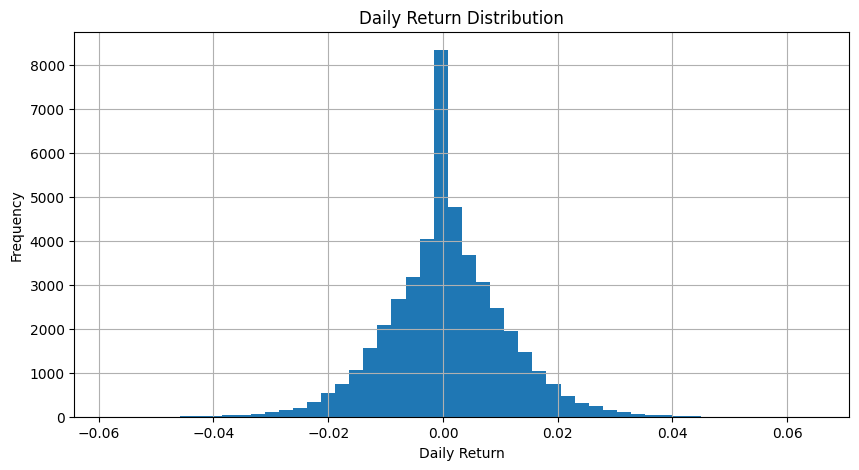

In [5]:
plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [6]:
daily_stats = nav.groupby(
    "amfi_code"
)["daily_return"].agg(
    ["mean","std"]
)

daily_stats.head()

,mean,std
amfi_code,,
100016,0.000142,0.009164
100025,0.000170,0.002460
100033,0.001080,0.011929
101206,0.000852,0.009177
101207,0.000424,0.016251


In [7]:
risk_free_rate = 0.065

sharpe_df = nav.groupby(
    "amfi_code"
)["daily_return"].agg(
    ["mean","std"]
).reset_index()

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["mean"]*252 - risk_free_rate)
    /
    (sharpe_df["std"]*np.sqrt(252))
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,mean,std,sharpe_ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101


In [8]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe CSV Saved")

Sharpe CSV Saved


In [9]:
cagr_list = []

for code, group in nav.groupby("amfi_code"):

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"]
         -
         group.iloc[0]["date"]).days
    ) / 365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
    ) - 1

    cagr_list.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [10]:
cagr_df.to_csv(
    "../reports/cagr_results.csv",
    index=False
)

print("CAGR CSV Saved")

CAGR CSV Saved


In [11]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"]
        /
        running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [code,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [12]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Drawdown CSV Saved")

Drawdown CSV Saved


In [13]:
scorecard = sharpe_df.merge(
    cagr_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

scorecard.head()

,amfi_code,mean,std,sharpe_ratio,cagr,max_drawdown
0,100016,0.000142,0.009164,-0.201517,0.026352,-0.247344
1,100025,0.000170,0.002460,-0.567095,0.044551,-0.043083
2,100033,0.001080,0.011929,1.093699,0.300997,-0.162172
3,101206,0.000852,0.009177,1.027213,0.235205,-0.112916
4,101207,0.000424,0.016251,0.162661,0.079331,-0.354469


In [14]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    returns = temp["daily_return"].dropna()

    downside = returns[returns < 0]

    downside_std = downside.std()

    mean_return = returns.mean()

    risk_free_daily = 0.065 / 252

    sortino = (
        (mean_return - risk_free_daily)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [15]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino CSV Saved")

Sortino CSV Saved


In [17]:
benchmark = (
    nav.groupby("date")["daily_return"]
    .mean()
    .reset_index()
)

benchmark.rename(
    columns={
        "daily_return":"benchmark_return"
    },
    inplace=True
)

In [18]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = fund_df.merge(
        benchmark,
        on="date"
    ).dropna()

    beta, alpha, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append(
        [
            fund,
            alpha * 252,
            beta
        ]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


In [19]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta CSV Saved")

Alpha Beta CSV Saved


In [20]:
top5 = (
    sharpe_df
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)

top5

,amfi_code,mean,std,sharpe_ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101


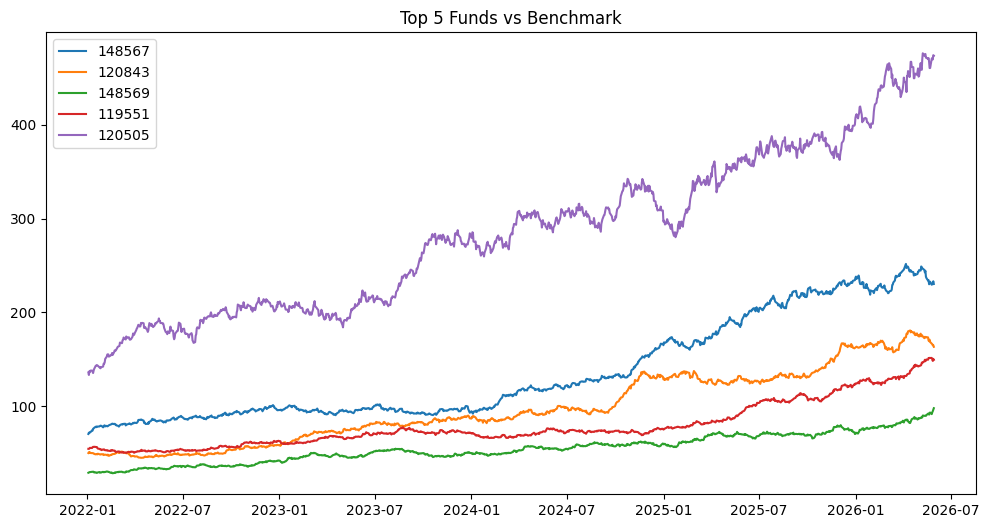

In [21]:
plt.figure(figsize=(12,6))

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.show()

In [22]:
plt.savefig(
    "../reports/benchmark_comparison.png"
)

<Figure size 640x480 with 0 Axes>

In [23]:
perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [24]:
perf = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

perf["return_rank"] = (
    perf["return_3yr_pct"]
    .rank(ascending=False)
)

perf["sharpe_rank"] = (
    perf["sharpe_ratio"]
    .rank(ascending=False)
)

perf["alpha_rank"] = (
    perf["alpha"]
    .rank(ascending=False)
)

perf["expense_rank"] = (
    perf["expense_ratio_pct"]
    .rank(ascending=True)
)

perf["drawdown_rank"] = (
    perf["max_drawdown_pct"]
    .rank(ascending=False)
)

perf["fund_score"] = (
    0.30 * perf["return_rank"]
    + 0.25 * perf["sharpe_rank"]
    + 0.20 * perf["alpha_rank"]
    + 0.15 * perf["expense_rank"]
    + 0.10 * perf["drawdown_rank"]
)

perf["fund_score"] = (
    100
    * (
        perf["fund_score"].max()
        - perf["fund_score"]
    )
    /
    (
        perf["fund_score"].max()
        - perf["fund_score"].min()
    )
)

scorecard = (
    perf.sort_values(
        "fund_score",
        ascending=False
    )
)

scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].head()

,scheme_name,fund_score
22,Kotak Flexicap Fund - Regular - Growth,100.000000
2,SBI Small Cap Fund - Regular Plan - Growth,97.761194
14,ICICI Pru Liquid Fund - Regular - Growth,97.512438
9,HDFC Short Term Debt Fund - Regular - Growth,97.014925
21,Kotak Emerging Equity Fund - Regular - Growth,93.034826


In [25]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Updated Scorecard Saved")

Updated Scorecard Saved
